In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

df = pd.read_csv("../data/processed/transactions_clean.csv", parse_dates=["InvoiceDate", "InvoiceMonth"])
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,CustomerID,Country,IsCancelled,InvoiceMonth,Revenue
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,False,2009-12-01,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,False,2009-12-01,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,False,2009-12-01,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom,False,2009-12-01,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,False,2009-12-01,30.0


In [2]:
print(f"Rows: {len(df):,}")
print(f"Unique customers: {df['CustomerID'].nunique():,}")
print(f"Unique products: {df['StockCode'].nunique():,}")
print(f"Countries: {df['Country'].nunique()}")
print(f"Date range: {df['InvoiceDate'].min()} to {df['InvoiceDate'].max()}")

Rows: 820,904
Unique customers: 5,895
Unique products: 4,639
Countries: 41
Date range: 2009-12-01 07:45:00 to 2011-12-09 12:50:00


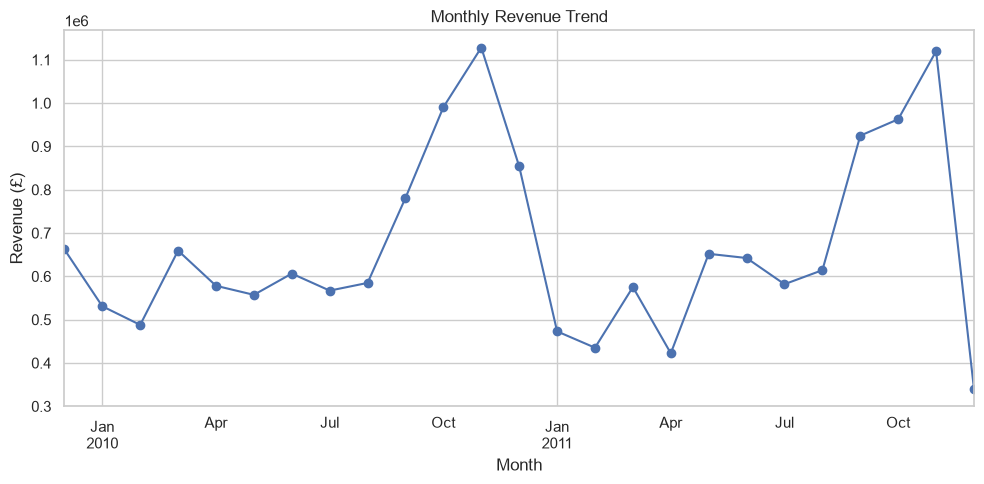

In [3]:
monthly_revenue = df.groupby("InvoiceMonth")["Revenue"].sum()

plt.figure(figsize=(10, 5))
monthly_revenue.plot(marker="o")
plt.title("Monthly Revenue Trend")
plt.ylabel("Revenue (£)")
plt.xlabel("Month")
plt.tight_layout()
plt.show()

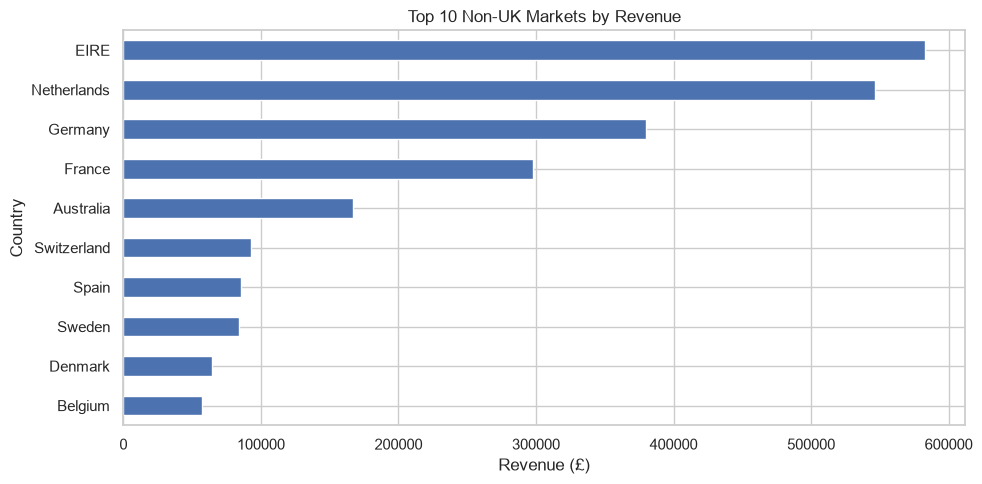

In [4]:
top_countries = (
    df[df["Country"] != "United Kingdom"]
    .groupby("Country")["Revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 5))
top_countries.plot(kind="barh")
plt.title("Top 10 Non-UK Markets by Revenue")
plt.xlabel("Revenue (£)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

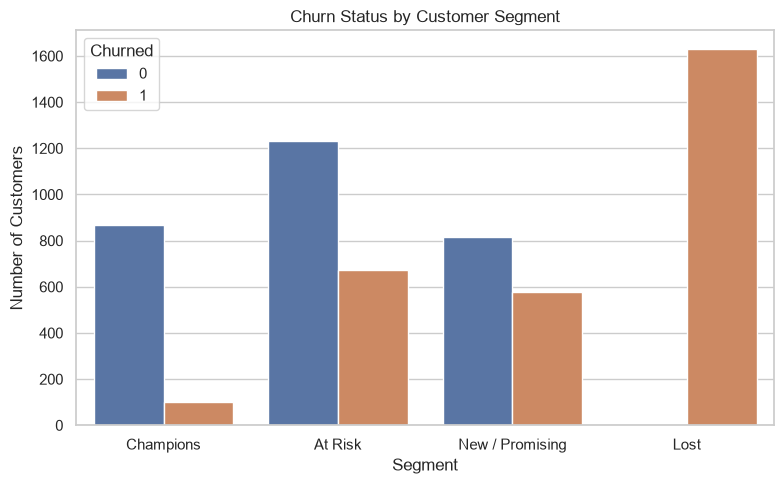

In [5]:
churn_df = pd.read_csv("../data/processed/customer_churn_predictions.csv")

plt.figure(figsize=(8, 5))
sns.countplot(data=churn_df, x="Segment", hue="Churned",
              order=["Champions", "At Risk", "New / Promising", "Lost"])
plt.title("Churn Status by Customer Segment")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()